In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models, datasets
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import re


train_dir = "/kaggle/input/butterflies/train_butterflies/"
test_dir = "/kaggle/input/butterflies/test_butterflies/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# предварительное исследование
classes = sorted([d for d in os.listdir(train_dir)])
# print(classes)

total = 0
balance_ = dict()
resolutions = set()

for class_ in classes:
    class_path = os.path.join(train_dir, class_)
    balance_[class_] = 0
    class_images = [_ for _ in os.listdir(class_path)]

    for image in class_images:
        img_path = os.path.join(class_path, image)
        total += 1
        balance_[class_] += 1
        with Image.open(img_path) as img:
            width, height = img.size
            resolutions.add((width, height))

balance = sorted(balance_.items(), key=lambda item: item[1])
print("Всего изображений", total) # 4955
print("Разрешение:", resolutions) # 224 * 224 

Всего изображений 4955
Разрешение: {(224, 224)}


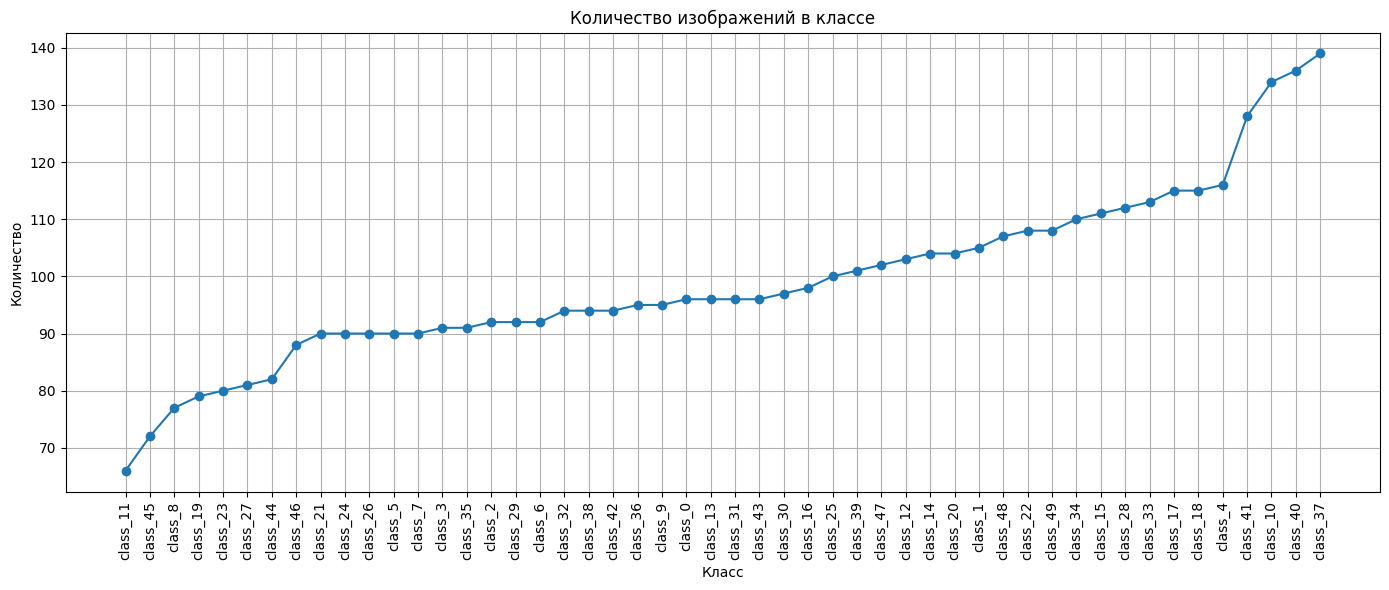

In [3]:
import matplotlib.pyplot as plt

classes = [item[0] for item in balance]
values = [item[1] for item in balance]

plt.figure(figsize=(14, 6))
plt.plot(classes, values, marker='o')
plt.xticks(rotation=90)
plt.title('Количество изображений в классе')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# функция для рисования кривых обучения
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_loss, label='Train Loss', linewidth=2)
    axes[0].plot(val_loss, label='Val Loss', linewidth=2)
    axes[0].set_title('Loss per Epoch', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(loc='upper right', fontsize=10)

    axes[1].plot(train_acc, label='Train Accuracy', linewidth=2)
    axes[1].plot(val_acc, label='Val Accuracy', linewidth=2)
    axes[1].set_title('Accuracy per Epoch', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(loc='lower right', fontsize=10)

    plt.show()

In [5]:
# подготовка данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # статистика ImageNet
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

train_ds, val_ds = random_split(train_dataset, [0.8, 0.2])

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [6]:
# датасет для тестовых данных
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted(
            [os.path.join(root_dir, f) for f in os.listdir(root_dir)],
            key=lambda x: int(re.search(r'(\d+)', os.path.basename(x)).group(1)) # регулярка находит число в имени файла
        )

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, os.path.basename(img_path)

    def __len__(self):
        return len(self.image_files)

test_dataset = TestDataset(root_dir=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
# первая модель - попытка натренировать с нуля
class BasicBlock1(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(64, 128, 1, stride=2, bias=False),
            nn.BatchNorm2d(128)
        )

    def forward(self, x):
        return (self.skip(x) + self.block(x)).relu()
    
class BasicBlock2(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )

    def forward(self, x):
        return (x + self.block(x)).relu()

model = nn.Sequential( # попробуем обучить не слишком глубокую сеть
    nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
    nn.BatchNorm2d(64),
    nn.MaxPool2d((3,3), stride=2, padding=1),
    BasicBlock1(),
    BasicBlock2(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(128, 50)
).to(device)


In [8]:
# функция обучения модели
def train_model(model, num_epochs, optimizer, criterion, name, scheduler=None):
    max_acc = 0
    
    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []
    
    for epoch in range(num_epochs):
        # тренировка
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_loss /= len(train_loader)
        
        # валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * correct / total
        val_loss /= len(val_loader)

        if scheduler is not None:
            scheduler.step(val_loss)
        
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")
    
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
    
        if max_acc < val_acc:
            max_acc = val_acc
            torch.save(model.state_dict(), name)

    plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

Epoch 1/50: 100%|██████████| 248/248 [00:12<00:00, 19.85it/s]


Train Loss: 3.1506 | Acc: 18.04%
Val Loss: 2.7480 | Acc: 24.32%


Epoch 2/50: 100%|██████████| 248/248 [00:11<00:00, 22.21it/s]


Train Loss: 2.6172 | Acc: 29.01%
Val Loss: 2.5183 | Acc: 32.90%


Epoch 3/50: 100%|██████████| 248/248 [00:11<00:00, 21.62it/s]


...

Train Loss: 0.4383 | Acc: 88.60%
Val Loss: 1.1501 | Acc: 69.63%


Epoch 49/50: 100%|██████████| 248/248 [00:11<00:00, 22.54it/s]


Train Loss: 0.4332 | Acc: 88.80%
Val Loss: 0.9672 | Acc: 72.55%


Epoch 50/50: 100%|██████████| 248/248 [00:11<00:00, 22.45it/s]


Train Loss: 0.4118 | Acc: 89.48%
Val Loss: 1.1222 | Acc: 69.32%


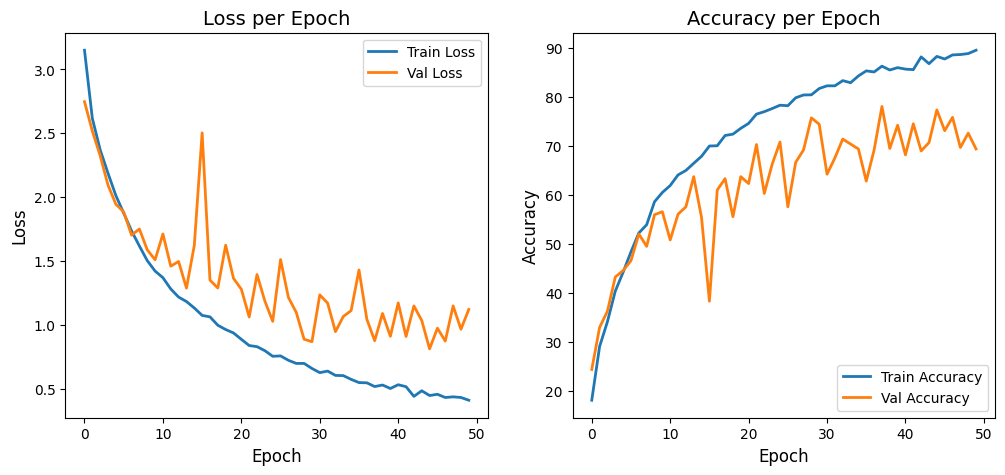

In [9]:
# обучим первую модель
opt = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)
loss_func = nn.CrossEntropyLoss()
train_model(model, 50, opt, loss_func, "first_model.pth") # поставил эпох побольше, чтобы потом прервать обучение при необходимости

In [10]:
# предсказание на тестовых данных
def form_prediction(name_of_data, model_to_predict, name_of_prediction):
    model_to_predict.eval()
    model_to_predict.load_state_dict(torch.load(name_of_data))
    all_preds = []
    filenames = []
    
    with torch.no_grad():
        for inputs, names in test_loader:
            inputs = inputs.to(device)
            outputs = model_to_predict(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            filenames.extend(names)
    
    class_names = train_dataset.classes
    class_preds = [class_names[p] for p in all_preds]
    
    results = []
    for i, (fn, pred) in enumerate(zip(filenames, class_preds)):
        class_num = int(pred.split('_')[1])
        results.append({'index': i, 'label': class_num})
    
    df = pd.DataFrame(results)
    df.to_csv(name_of_prediction, index=False)

In [11]:
# первая модель достигает порога 0.8 на валидационной выборке
# скорее всего, у нее недостаточная глубина

form_prediction("first_model.pth", model, "first_model_prediction.csv")

In [12]:
# вторая модель - дообученная b3
class ButterflyClassifier(nn.Module):
    def __init__(self): # внезапно, работает лучше без заморозки слоев, я проверял!
        super().__init__()
        self.base_model = models.efficientnet_b3(pretrained=True)
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(self.base_model.classifier[1].in_features, 50)
        )
    
    def forward(self, x):
        return self.base_model(x)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 198MB/s]
Epoch 1/15: 100%|██████████| 248/248 [00:38<00:00,  6.52it/s]


Train Loss: 1.1599 | Acc: 71.29%
Val Loss: 0.6317 | Acc: 83.96%


Epoch 2/15: 100%|██████████| 248/248 [00:37<00:00,  6.57it/s]


Train Loss: 0.3396 | Acc: 90.16%
Val Loss: 0.5872 | Acc: 88.50%


Epoch 3/15: 100%|██████████| 248/248 [00:37<00:00,  6.57it/s]


...

Train Loss: 0.0751 | Acc: 97.70%
Val Loss: 0.5458 | Acc: 92.23%


Epoch 14/15: 100%|██████████| 248/248 [00:38<00:00,  6.51it/s]


Train Loss: 0.0477 | Acc: 98.49%
Val Loss: 0.6303 | Acc: 90.82%


Epoch 15/15: 100%|██████████| 248/248 [00:38<00:00,  6.52it/s]


Train Loss: 0.0509 | Acc: 98.11%
Val Loss: 0.5962 | Acc: 90.51%


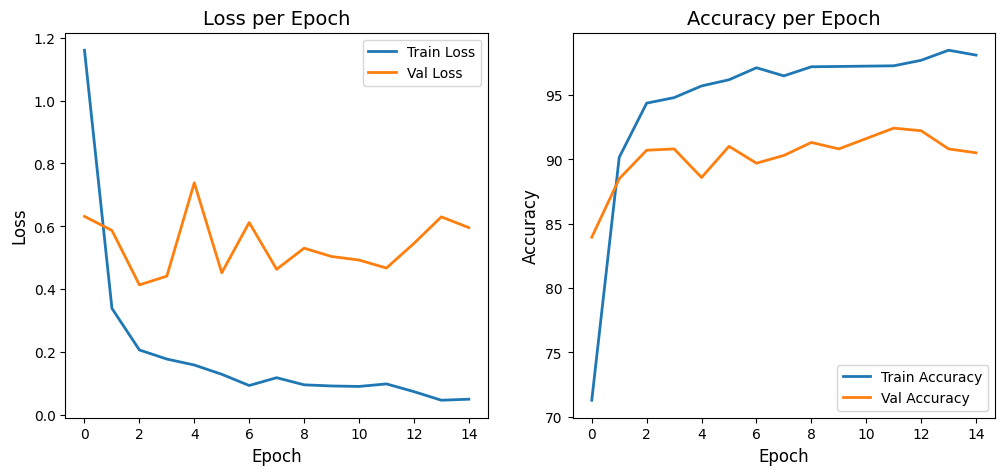

In [13]:
model = ButterflyClassifier().to(device)

loss_func = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001)

train_model(model, 15, opt, loss_func, "second_model.pth")

In [14]:
form_prediction("second_model.pth", model, "second_model_prediction.csv")

In [15]:
# попробуем изменить последнюю модель
class ButterflyClassifierUpdated(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.efficientnet_b3(pretrained=True)
        self.base_model.classifier = nn.Sequential( # пробовал менять последние слои, эта архитектура показала себя лучше всего
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(self.base_model.classifier[1].in_features, 50)
        )
    
    def forward(self, x):
        return self.base_model(x)

In [16]:
# добавим аугментации
aug_transform = transforms.Compose([
    transforms.RandomAffine(degrees=(-20, 20), translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.)),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.1),
    transforms.RandomAdjustSharpness(1.5, p=0.3),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# придется заново создать датасеты
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=None
)

train_tmp, val_tmp = random_split(train_dataset, [0.95, 0.05]) # для итогового предсказания обучим на большем количестве данных

In [17]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_ds = TransformSubset(train_tmp, aug_transform)
val_ds = TransformSubset(val_tmp, transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

Epoch 1/30: 100%|██████████| 295/295 [01:19<00:00,  3.69it/s]


Train Loss: 3.4867 | Acc: 25.66%
Val Loss: 2.5621 | Acc: 66.80%


Epoch 2/30: 100%|██████████| 295/295 [01:19<00:00,  3.72it/s]


Train Loss: 1.7656 | Acc: 71.56%
Val Loss: 1.0303 | Acc: 82.59%


Epoch 3/30: 100%|██████████| 295/295 [01:18<00:00,  3.74it/s]


...

Train Loss: 0.0330 | Acc: 99.17%
Val Loss: 0.2218 | Acc: 95.55%


Epoch 29/30: 100%|██████████| 295/295 [01:21<00:00,  3.61it/s]


Train Loss: 0.0302 | Acc: 99.47%
Val Loss: 0.2468 | Acc: 95.55%


Epoch 30/30: 100%|██████████| 295/295 [01:20<00:00,  3.67it/s]


Train Loss: 0.0313 | Acc: 99.41%
Val Loss: 0.2318 | Acc: 95.95%


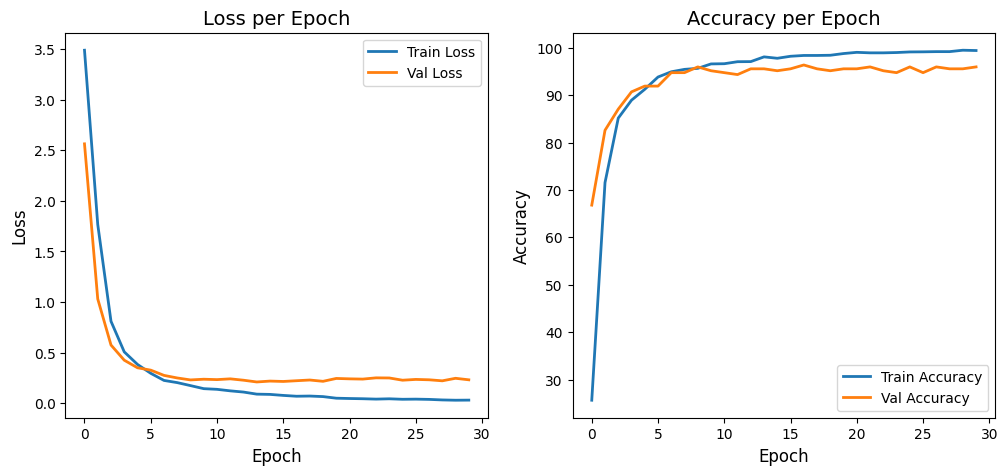

In [18]:
model = ButterflyClassifierUpdated().to(device)
opt = optim.Adam(model.parameters(), lr=0.00005, amsgrad=True) # .0001
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2) # без планировщика лучше
loss_func = nn.CrossEntropyLoss()
train_model(model, 30, opt, loss_func, "third_model.pth") # больше эпох, так как модель сложнее

In [19]:
form_prediction("third_model.pth", model, "third_model_prediction.csv")